# Testing foreground/background separation


In [33]:
import pylidc as pl
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

# Make plots a bit larger and cleaner
plt.rcParams["figure.figsize"] = (7, 7)
plt.rcParams["image.cmap"] = "gray"

# Constants used in the notebook
LUNG_HU_THRESHOLD = -500
HU_MIN = -1000
HU_MAX = 400


## Load one scan, get one slice

CT scan = 3D volume
- axis 0 = up/down
- axis 1 = left/right
- axis 2 = slice number

Just assume we take middle slice of the volume


In [34]:
# Load the first scan available in ds
scan = pl.query(pl.Scan).first()

# Convert the scan to a 3D NumPy volume
vol = scan.to_volume()

# Choose the middle slice
slice_idx = vol.shape[2] // 2
raw_slice = vol[:, :, slice_idx]

print(f"Patient:  {scan.patient_id}")
print(f"Volume shape: {vol.shape}")
print(f"Slice chosen: {slice_idx} of {vol.shape[2]}")
print(f"HU range in this slice: {raw_slice.min():.0f} to {raw_slice.max():.0f}")


Loading dicom files ... This may take a moment.
Patient:  LIDC-IDRI-0078
Volume shape: (512, 512, 87)
Slice chosen: 43 of 87
HU range in this slice: -2048 to 1398


## Original CT slice
Then we:
- Clip HU Values
- Normalise


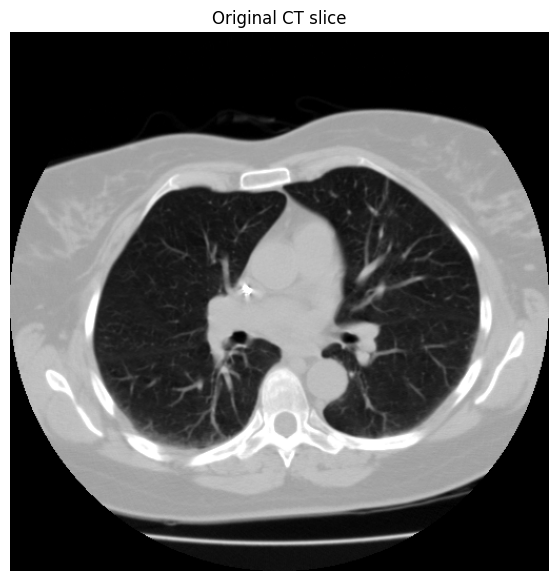

In [35]:
def normalize_for_display(img, hu_min=HU_MIN, hu_max=HU_MAX):
    clipped = np.clip(img, hu_min, hu_max)
    return (clipped - hu_min) / (hu_max - hu_min)

display = normalize_for_display(raw_slice)

plt.imshow(display)
plt.title("Original CT slice")
plt.axis("off")
plt.show()


## Threshold 1:-500

- lungs + 0utside body = full of air = very low HU
- Threshhold catches: lungs + outside air + other dark regions

- White (True / 1) → pixels below -500 HU
- Black (False / 0) → pixels above -500 HU

Too Broad of threshold


Number of pixels below threshold: 148651


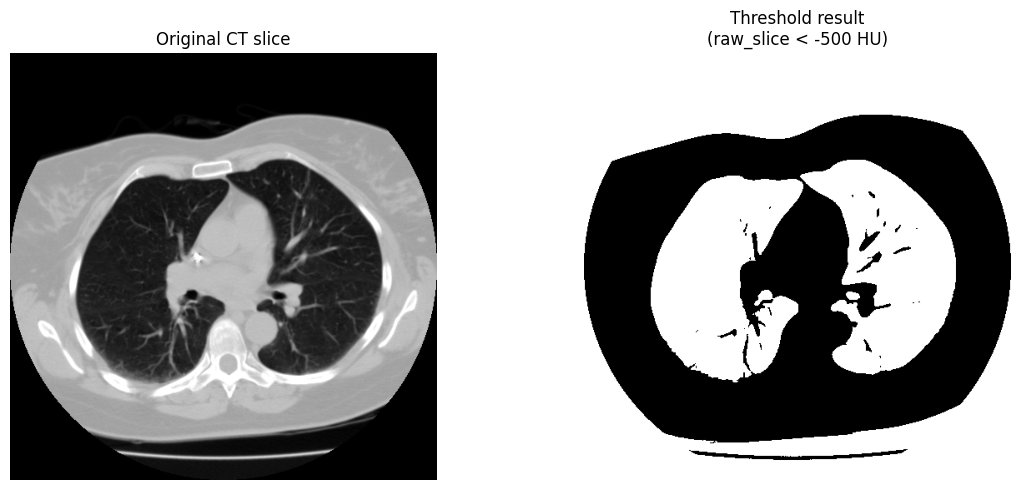

In [36]:
# Pixels below the threshold are treated as "air-like"
binary = raw_slice < LUNG_HU_THRESHOLD

print("Number of pixels below threshold:", binary.sum())

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(display)
ax[0].set_title("Original CT slice")
ax[0].axis("off")

ax[1].imshow(binary)
ax[1].set_title(f"Threshold result\n(raw_slice < {LUNG_HU_THRESHOLD} HU)")
ax[1].axis("off")

plt.tight_layout()
plt.show()


## Find Regions - separate which parts are which


Connected regions found: 6


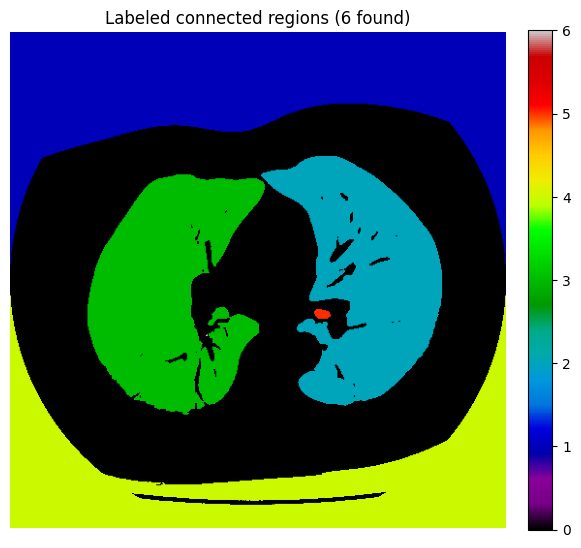

In [37]:
labeled, num_features = ndimage.label(binary)
print(f"Connected regions found: {num_features}")
plt.figure(figsize=(7, 7))
plt.imshow(labeled, cmap="nipy_spectral")
plt.title(f"Labeled connected regions ({num_features} found)")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)
plt.show()


## Remove outside air (the ones that touch the imagte border)
### Removes Black, Blue, Yellow
The outside background air
- touches image border
- lungs sit inside the body, do not touch the border


In [38]:
# Collect labels seen on the border of the image
border_labels = set()
border_labels.update(labeled[0, :])    # top row
border_labels.update(labeled[-1, :])   # bottom row
border_labels.update(labeled[:, 0])    # left column
border_labels.update(labeled[:, -1])   # right column

# 0 means "no region", so remove it from the set
border_labels.discard(0)

# Create a mask showing only the border-connected regions
border_mask = np.isin(labeled, list(border_labels))

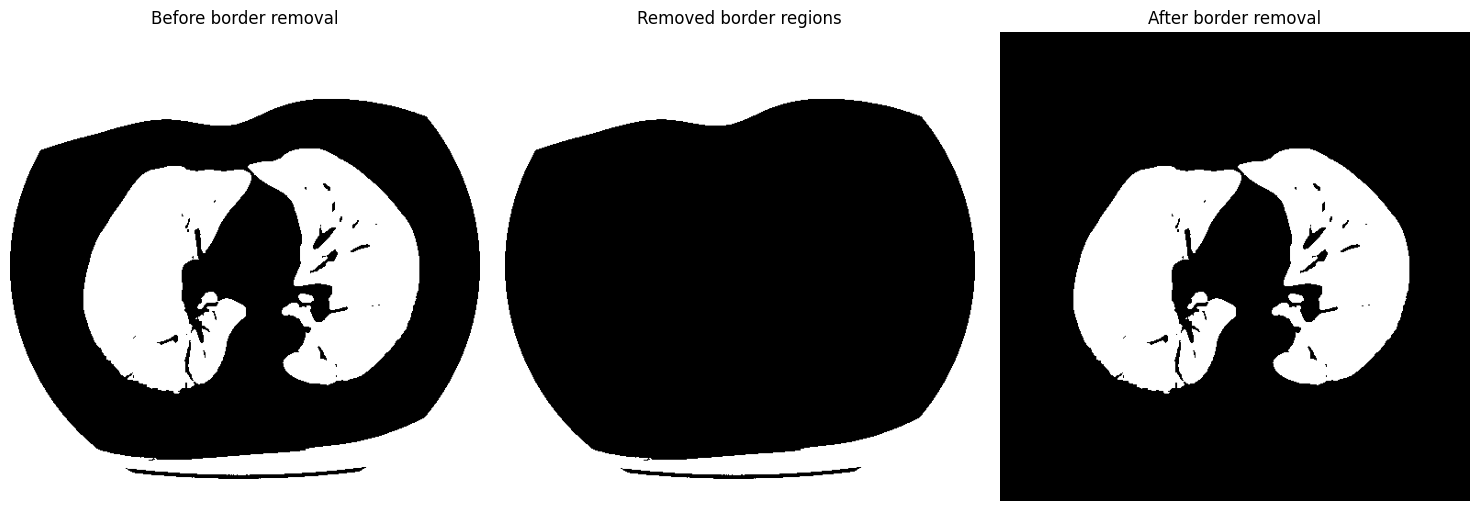

In [39]:
labeled_no_border = labeled.copy()

for lbl in border_labels:
    labeled_no_border[labeled_no_border == lbl] = 0

binary_internal = labeled_no_border > 0

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(binary)
ax[0].set_title("Before border removal")
ax[0].axis("off")

ax[1].imshow(border_mask)
ax[1].set_title("Removed border regions")
ax[1].axis("off")

ax[2].imshow(binary_internal)
ax[2].set_title("After border removal")
ax[2].axis("off")

plt.tight_layout()
plt.show()


## Re-label internal regions

Internal regions after border removal: 4


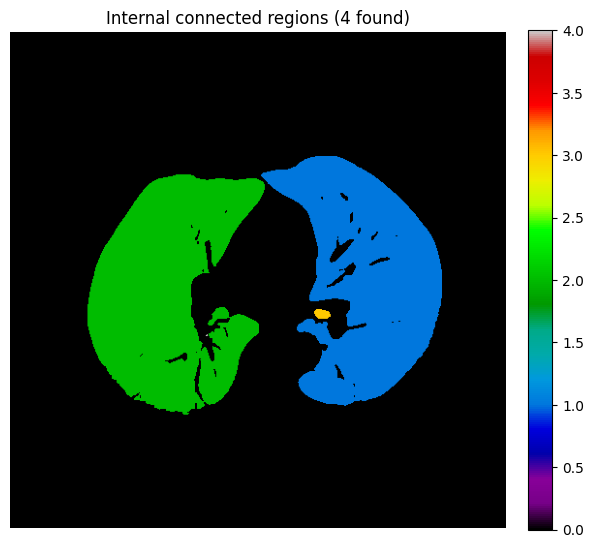

In [40]:
labeled2, num2 = ndimage.label(binary_internal)
print(f"Internal regions after border removal: {num2}")

plt.figure(figsize=(7, 7))
plt.imshow(labeled2, cmap="nipy_spectral")
plt.title(f"Internal connected regions ({num2} found)")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)
plt.show()


## Measure each internal region, keep only 2 biggest regions

In [41]:
if num2 == 0:
    region_sizes = np.array([])
else:
    region_sizes = ndimage.sum(binary_internal, labeled2, range(1, num2 + 1))

print("Region sizes:")
for i, sz in enumerate(region_sizes, start=1):
    print(f"  Label {i}: {int(sz)} pixels")

# Pick the largest one or two regions
n_keep = min(2, len(region_sizes))
sorted_idx = np.argsort(region_sizes)[::-1]
keep_labels = sorted_idx[:n_keep] + 1

print("Labels kept as lung candidates:", keep_labels)


Region sizes:
  Label 1: 26863 pixels
  Label 2: 28917 pixels
  Label 3: 133 pixels
  Label 4: 3 pixels
Labels kept as lung candidates: [2 1]


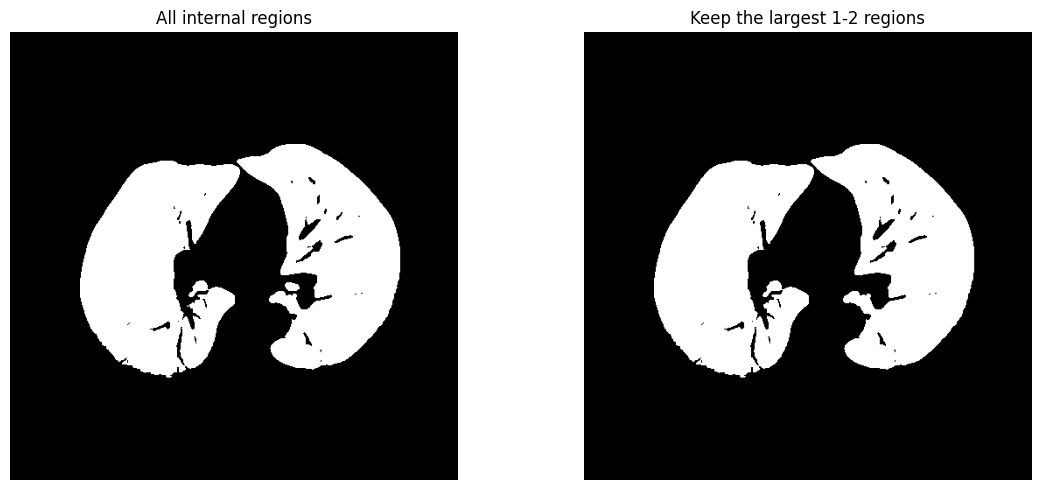

In [42]:
largest_regions_mask = np.zeros_like(binary_internal, dtype=bool)

for lbl in keep_labels:
    largest_regions_mask |= (labeled2 == lbl)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(binary_internal)
ax[0].set_title("All internal regions")
ax[0].axis("off")

ax[1].imshow(largest_regions_mask)
ax[1].set_title("Keep the largest 1-2 regions")
ax[1].axis("off")

plt.tight_layout()
plt.show()


## 9) Fill holes inside the lungs

Therse are the
- vessels
- bronchi / airways
- partial-volume effects

Use `binary_fill_holes`


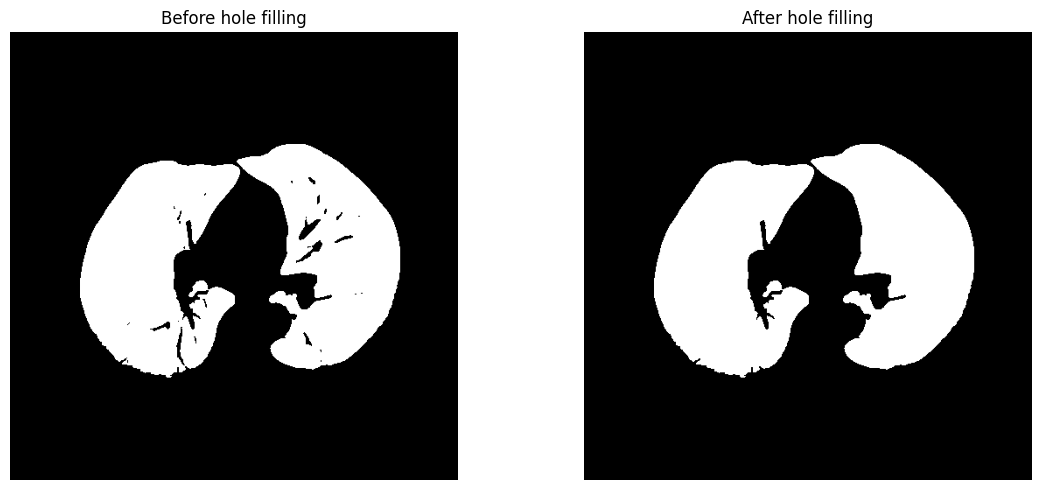

In [43]:
filled_mask = ndimage.binary_fill_holes(largest_regions_mask)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(largest_regions_mask)
ax[0].set_title("Before hole filling")
ax[0].axis("off")

ax[1].imshow(filled_mask)
ax[1].set_title("After hole filling")
ax[1].axis("off")

plt.tight_layout()
plt.show()


## Cleanup - bbinary opening?

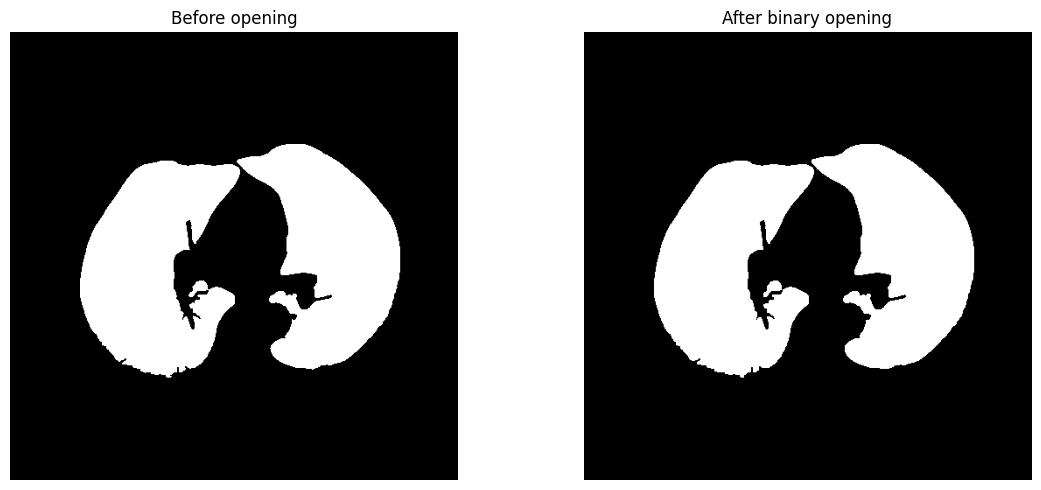

In [44]:
opened_mask = ndimage.binary_opening(
    filled_mask,
    structure=np.ones((3, 3))
)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(filled_mask)
ax[0].set_title("Before opening")
ax[0].axis("off")

ax[1].imshow(opened_mask)
ax[1].set_title("After binary opening")
ax[1].axis("off")

plt.tight_layout()
plt.show()


## Final mask

Lung mask pixels: 56736
Non-lung pixels: 205408


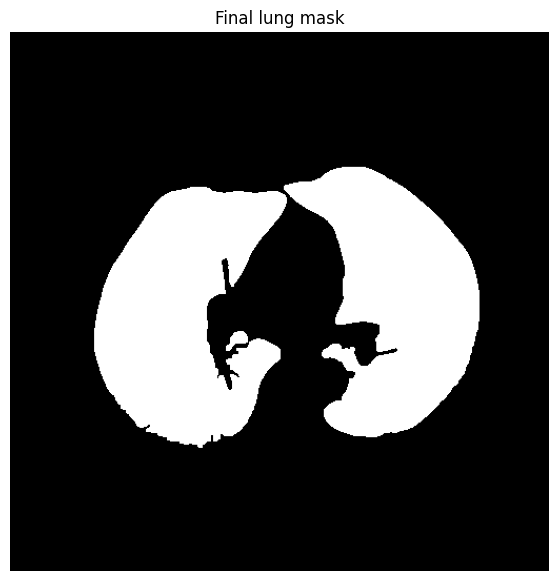

In [45]:
clean_mask = opened_mask.astype(np.uint8)

print(f"Lung mask pixels: {clean_mask.sum()}")
print(f"Non-lung pixels: {(~clean_mask.astype(bool)).sum()}")

plt.figure(figsize=(7, 7))
plt.imshow(clean_mask)
plt.title("Final lung mask")
plt.axis("off")
plt.show()


## Overlay mask on the CT


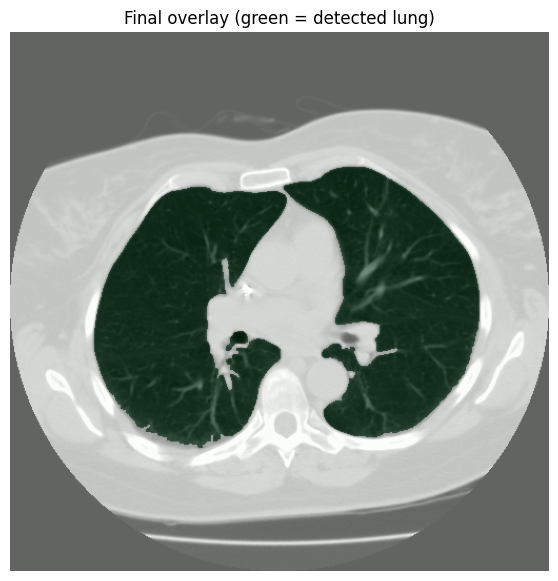

In [ ]:
plt.figure(figsize=(7, 7))
plt.imshow(display, cmap="gray")
plt.imshow(clean_mask, cmap="Greens", alpha=0.4)
plt.title("Final overlay (green = detected lung)")``
plt.axis("off")
plt.show()


## SUMMARY

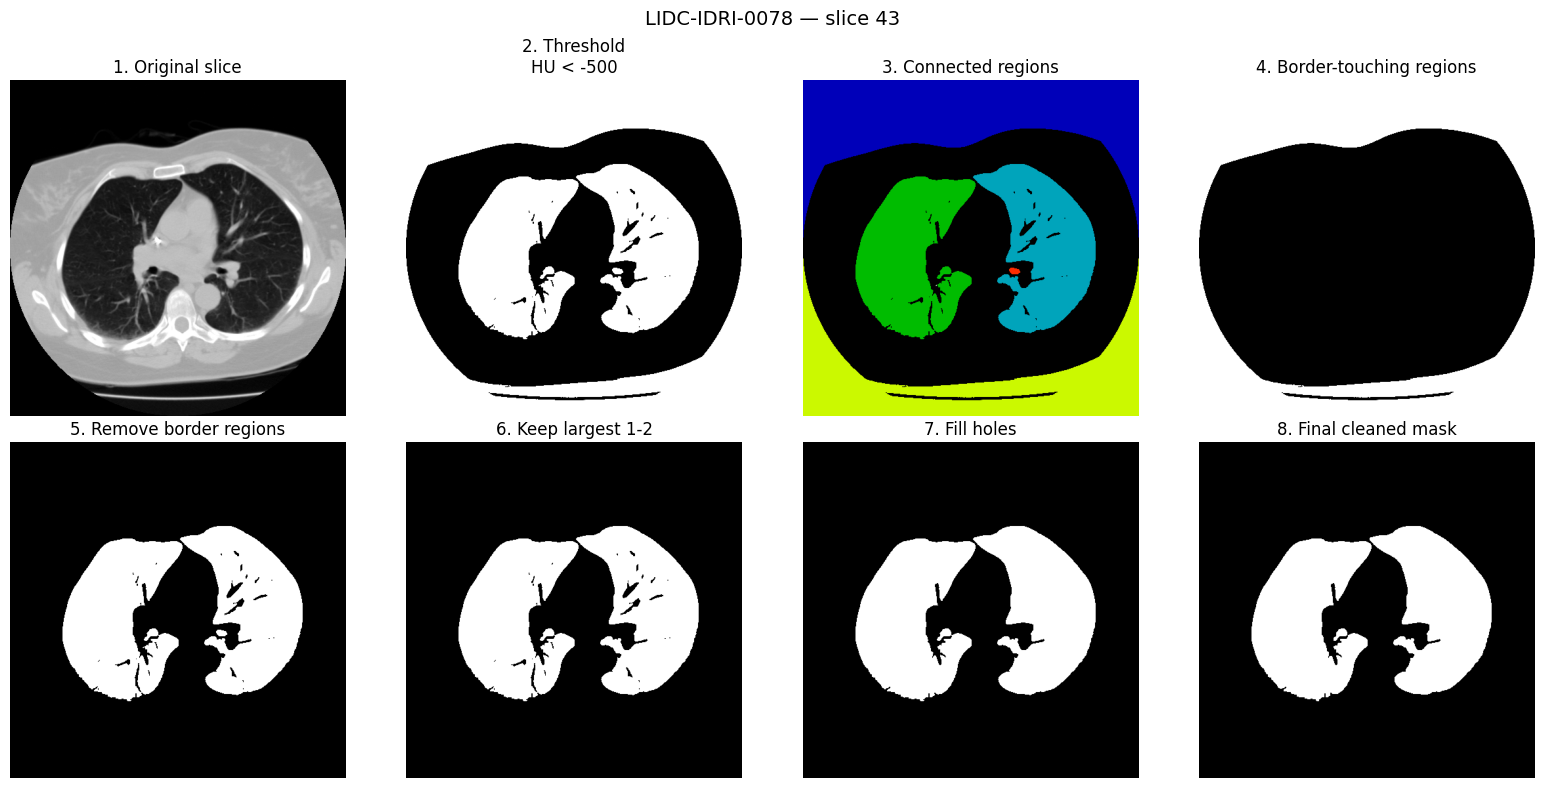

In [47]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

steps = [
    (display, "1. Original slice"),
    (binary, f"2. Threshold\nHU < {LUNG_HU_THRESHOLD}"),
    (labeled, "3. Connected regions"),
    (border_mask, "4. Border-touching regions"),
    (binary_internal, "5. Remove border regions"),
    (largest_regions_mask, "6. Keep largest 1-2"),
    (filled_mask, "7. Fill holes"),
    (clean_mask, "8. Final cleaned mask"),
]

for ax, (img, title) in zip(axes.ravel(), steps):
    if "Connected regions" in title:
        ax.imshow(img, cmap="nipy_spectral")
    else:
        ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.suptitle(f"{scan.patient_id} — slice {slice_idx}", fontsize=14)
plt.tight_layout()
plt.show()
